#Ejercicio taller evolución de imágenes

Genere aleatoriamente una población de 50 matrices de 120 por 180, con números de 0 a 255, preséntelas como una gráfica RGB. La función de aptitud es una imagen cualquiera. Evolucione la población inicial hasta llegar a la imagen.

**Configuración**:

- Población: 100 individuos.
- Tamaño imagen: 120×180 píxeles, 3 canales (RGB).
- Aptitud : medida por el Error Cuadrático Medio (MSE) entre la imagén generada y la imagen objetivo. Objetico es minimizar ese objetivo, entonces entre menor es MSE mas apta es la imágen.
- Operadores:
Torneo: De un suconjunto de individuos se toman los individuos con mejores aptitudes.
Cruce: se escoje dos imagenes y hay una probabilidad del 50% de escojer si se tomará el pixel de el padre A o del padre B.
Mutación: evitando que la población se estanque se escoge una mutación baja




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

IMG_H, IMG_W = 120, 180
POP_SIZE = 50

# Funciones auxiliares
def make_random_image(h=IMG_H, w=IMG_W, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return rng.integers(0,256, size=(h,w,3), dtype=np.uint8)

def show_image(ax, img, title=None):
    ax.imshow(img.astype(np.uint8))
    ax.axis('off')
    if title is not None:
        ax.set_title(title, fontsize=10)

def initialize_population(pop_size=POP_SIZE, h=IMG_H, w=IMG_W, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return rng.integers(0,256, size=(pop_size,h,w,3), dtype=np.uint8)

def mse_batch(pop, target):
    diff = pop.astype(np.int32) - target.astype(np.int32)
    mse = np.mean(diff*diff, axis=(1,2,3))
    return mse


## Operadores evolutivos

In [9]:
# Operadores y bucle evolutivo
def tournament_select(pop, mse, k=3, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = pop.shape[0]
    idxs = rng.integers(0, N, size=(N, k))
    selected = []
    for row in idxs:
        best = row[np.argmin(mse[row])]
        selected.append(best)
    return np.array(selected, dtype=int)

def uniform_crossover(parent_a, parent_b, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    mask = rng.random(parent_a.shape) < 0.5
    child = np.where(mask, parent_a, parent_b).astype(np.uint8)
    return child

def mutate_image(img, mutation_prob_pixel=1e-3, mutation_std=15, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    img = img.astype(np.int32)
    mask = rng.random(img.shape) < mutation_prob_pixel
    if not mask.any():
        return img.astype(np.uint8)
    noise = rng.normal(loc=0.0, scale=mutation_std, size=img.shape).astype(np.int32)
    img[mask] += noise[mask]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def evolve(pop, target, max_gens=6000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = pop.shape[0]
    history = []
    mse = mse_batch(pop, target)
    best_idx = int(np.argmin(mse))
    history.append(mse[best_idx])
    for gen in range(1, max_gens+1):
        sel_idxs = tournament_select(pop, mse, k=3, rng=rng)
        parents = pop[sel_idxs]
        offspring = np.empty_like(parents)
        for i in range(0, N, 2):
            a = parents[i]
            b = parents[i+1 if i+1<N else 0]
            if rng.random() < 0.9:
                child1 = uniform_crossover(a, b, rng=rng)
                child2 = uniform_crossover(b, a, rng=rng)
            else:
                child1 = a.copy(); child2 = b.copy()
            child1 = mutate_image(child1, mutation_prob_pixel=1e-3, mutation_std=15, rng=rng)
            child2 = mutate_image(child2, mutation_prob_pixel=1e-3, mutation_std=15, rng=rng)
            offspring[i] = child1
            if i+1 < N:
                offspring[i+1] = child2
        pop = offspring
        mse = mse_batch(pop, target)
        best_idx = int(np.argmin(mse))
        history.append(mse[best_idx])
        if gen % 10 == 0:
            print(f'Gen {gen}: best MSE = {history[-1]:.2f}')
        if mse[best_idx] == 0:
            print('Perfect match found at generation', gen)
            break
    best_idx = int(np.argmin(mse))
    return pop, np.array(history), pop[best_idx], mse[best_idx]


## Ejecución del código
generando una imagen target también genero padres aleatorios, luego comparo la imágen con la imágen target, luego tengo la mejor población hija, y con cruces genero una nueva población, gracias a las mutaciones y se escoge la población con mayor aptitud, para poder tener una imagen parecida se debe hacer varias veces el mismo bucle, en este código se hicieron 10000 generaciones para tener una imágen que se parece bastante a la real.

Población y target creados. Ejecutando evolución...
Gen 10: best MSE = 10313.29
Gen 20: best MSE = 10146.94
Gen 30: best MSE = 10027.09
Gen 40: best MSE = 9950.82
Gen 50: best MSE = 9879.81
Gen 60: best MSE = 9840.37
Gen 70: best MSE = 9818.58
Gen 80: best MSE = 9797.70
Gen 90: best MSE = 9785.85
Gen 100: best MSE = 9778.72
Gen 110: best MSE = 9769.61
Gen 120: best MSE = 9759.85
Gen 130: best MSE = 9752.80
Gen 140: best MSE = 9745.44
Gen 150: best MSE = 9739.00
Gen 160: best MSE = 9730.45
Gen 170: best MSE = 9722.96
Gen 180: best MSE = 9716.28
Gen 190: best MSE = 9709.26
Gen 200: best MSE = 9700.64
Gen 210: best MSE = 9692.32
Gen 220: best MSE = 9683.49
Gen 230: best MSE = 9677.04
Gen 240: best MSE = 9668.15
Gen 250: best MSE = 9659.30
Gen 260: best MSE = 9649.52
Gen 270: best MSE = 9643.13
Gen 280: best MSE = 9635.14
Gen 290: best MSE = 9626.98
Gen 300: best MSE = 9618.54
Gen 310: best MSE = 9609.48
Gen 320: best MSE = 9603.52
Gen 330: best MSE = 9595.76
Gen 340: best MSE = 9588.46
Ge

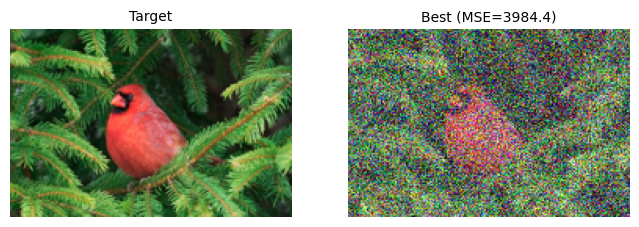

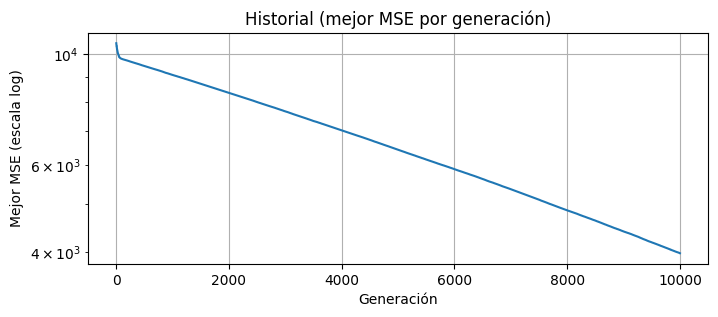

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image # Importar la librería Pillow

# Uso: crear target, inicializar población y ejecutar
rng = np.random.default_rng(42)

try:

    img_path = '/content/sample_data/dog.jpg' #ruta de mi imagen
    target_pil = Image.open(img_path).convert('RGB')
    target = np.array(target_pil.resize((IMG_W, IMG_H)))
except FileNotFoundError:
    print(f"Advertencia: No se encontró la imagen '{img_path}'. Se usará una imagen aleatoria como target.")
    target = make_random_image(rng=rng)
# ------------------------------------------------------------------

pop = initialize_population(rng=rng)

print('Población y target creados. Ejecutando evolución...')
pop, history, best_img, best_mse = evolve(pop, target, max_gens=10000, rng=rng)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(8,4))
show_image(ax[0], target, title='Target')
show_image(ax[1], best_img, title=f'Best (MSE={best_mse:.1f})')
plt.show()

plt.figure(figsize=(8,3))
plt.plot(history)
plt.yscale('log')
plt.title('Historial (mejor MSE por generación)')
plt.xlabel('Generación')
plt.ylabel('Mejor MSE (escala log)')
plt.grid(True)
plt.show()